In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/취업 포폴/ashrae 에너지 예측 분석/data collection/data.csv')


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 이상치 원인 분석

          building_id  meter  site_id primary_use            timestamp  \
8907488          1099      2       13   Education  2016-06-13 09:00:00   
8738539          1099      2       13   Education  2016-06-10 09:00:00   
8736187          1099      2       13   Education  2016-06-10 08:00:00   
17286421         1099      2       13   Education  2016-11-09 14:00:00   
8905140          1099      2       13   Education  2016-06-13 08:00:00   
17284060         1099      2       13   Education  2016-11-09 13:00:00   
3803586          1099      2       13   Education  2016-03-12 21:00:00   
8628165          1099      2       13   Education  2016-06-08 10:00:00   
8630513          1099      2       13   Education  2016-06-08 11:00:00   
9066997          1099      2       13   Education  2016-06-16 05:00:00   
8424091          1099      2       13   Education  2016-06-04 19:00:00   
3601356          1099      2       13   Education  2016-03-08 21:00:00   
8534327          1099      2       13 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

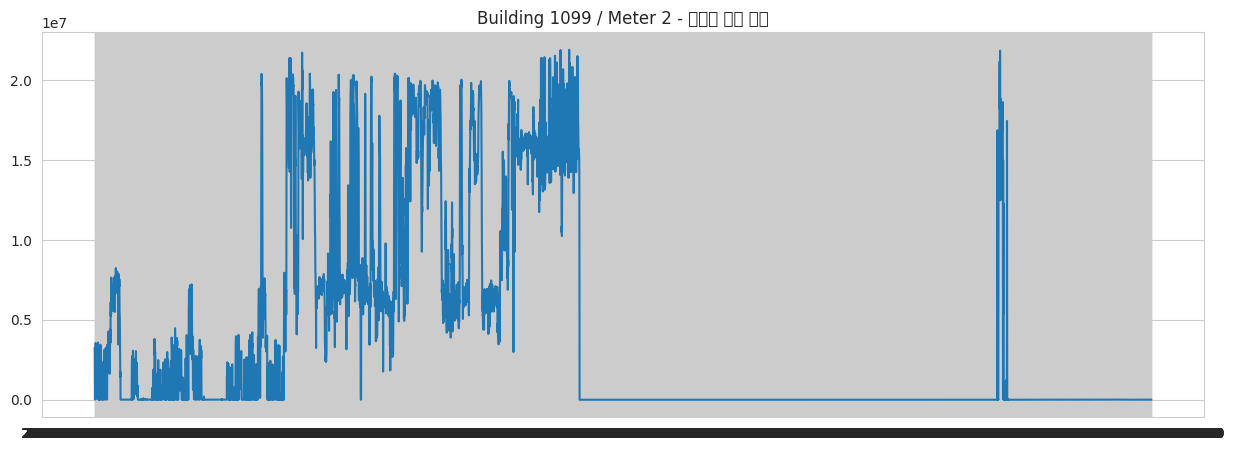

/tmp/ipykernel_22176/1104330341.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_ratio_by_meter = df.groupby('meter').apply(iqr_outlier_ratio)


meter
0    0.107313
1    0.111656
2    0.125402
3    0.127155
dtype: float64
0값 비율: 9.27%
meter
0    0.043958
1    0.156967
2    0.128090
3    0.269251
dtype: float64


/tmp/ipykernel_22176/1104330341.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_by_meter = df.groupby('meter').apply(lambda g: (g['meter_reading']==0).mean())


In [4]:
import matplotlib.pyplot as plt


# 1) 극단값 상위 20개 확인 - 어떤 building/meter/site에서 나오는지
top_outliers = df.nlargest(20, 'meter_reading')[
    ['building_id', 'meter', 'site_id', 'primary_use', 'timestamp', 'meter_reading']
]
print(top_outliers)

# 2) meter별 극단값 분포 - 특정 meter 타입에 몰려있는지 확인
print(df.groupby('meter')['meter_reading'].describe())

# 3) building_id별 최대값 - 특정 건물이 반복적으로 극단값을 내는지 확인
building_max = df.groupby('building_id')['meter_reading'].max().sort_values(ascending=False)
print(building_max.head(20))

# 4) 특정 건물의 시계열 패턴 확인 (예: 최대 이상치를 낸 건물)
suspect_building = top_outliers.iloc[0]['building_id']
suspect_meter = top_outliers.iloc[0]['meter']

subset = df[(df['building_id'] == suspect_building) & (df['meter'] == suspect_meter)]
plt.figure(figsize=(15,5))
plt.plot(subset['timestamp'], subset['meter_reading'])
plt.title(f'Building {suspect_building} / Meter {suspect_meter} - 이상치 패턴 확인')
plt.show()

# 5) IQR 기준 이상치 비율 (meter별로 분리해서 계산 - meter마다 스케일이 다르므로)
def iqr_outlier_ratio(group):
    q1 = group['meter_reading'].quantile(0.25)
    q3 = group['meter_reading'].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    ratio = (group['meter_reading'] > upper).mean()
    return ratio

outlier_ratio_by_meter = df.groupby('meter').apply(iqr_outlier_ratio)
print(outlier_ratio_by_meter)

# 6) meter_reading = 0 인 비율도 확인 (실제로 캐글 ASHRAE 데이터는 0값이 매우 많은 게 알려진 이슈)
zero_ratio = (df['meter_reading'] == 0).mean()
print(f'0값 비율: {zero_ratio:.2%}')

zero_by_meter = df.groupby('meter').apply(lambda g: (g['meter_reading']==0).mean())
print(zero_by_meter)

In [5]:
# 시간
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Correlation Heatmap

In [6]:
import numpy as np

# 수치형 변수만 선택
numeric_cols = ['meter_reading', 'square_feet', 'year_built', 'floor_count',
                 'air_temperature', 'cloud_coverage', 'dew_temperature',
                 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction',
                 'wind_speed', 'hour', 'dayofweek', 'month']

corr = df[numeric_cols].corr()

# plt.figure(figsize=(12,10))
# sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
# plt.title('Correlation Heatmap')
# plt.show()

# meter_reading과의 상관관계만 정렬해서 보기 (더 직관적)
# corr_with_target = corr['meter_reading'].sort_values(ascending=False)
# print(corr_with_target)

# log 변환한 meter_reading으로도 확인 (분포가 왜곡되어있으니 원본보다 더 의미있을 수 있음)
df['log_meter_reading'] = np.log1p(df['meter_reading'])
corr_log = df[numeric_cols + ['log_meter_reading']].drop(columns='meter_reading').corr()
corr_log['log_meter_reading'].sort_values(ascending=False)

,log_meter_reading
log_meter_reading,1.000000
square_feet,0.366016
floor_count,0.342052
year_built,0.103332
month,0.047386
hour,0.033277
dew_temperature,0.008357
precip_depth_1_hr,0.002923
air_temperature,-0.004705
sea_level_pressure,-0.008588


# 결측치 처리 전략


In [7]:
# 결측 비율 재확인 (컬럼별 %)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct)

floor_count           82.652772
year_built            59.990033
cloud_coverage        43.655131
precip_depth_1_hr     18.544739
wind_direction         7.167792
sea_level_pressure     6.092515
wind_speed             0.710701
dew_temperature        0.495348
air_temperature        0.478124
time_diff              0.448148
building_id            0.000000
timestamp              0.000000
meter                  0.000000
site_id                0.000000
meter_reading          0.000000
square_feet            0.000000
primary_use            0.000000
hour                   0.000000
dayofweek              0.000000
month                  0.000000
log_meter_reading      0.000000
dtype: float64


# 데이터 전처리

## 이상치 처리

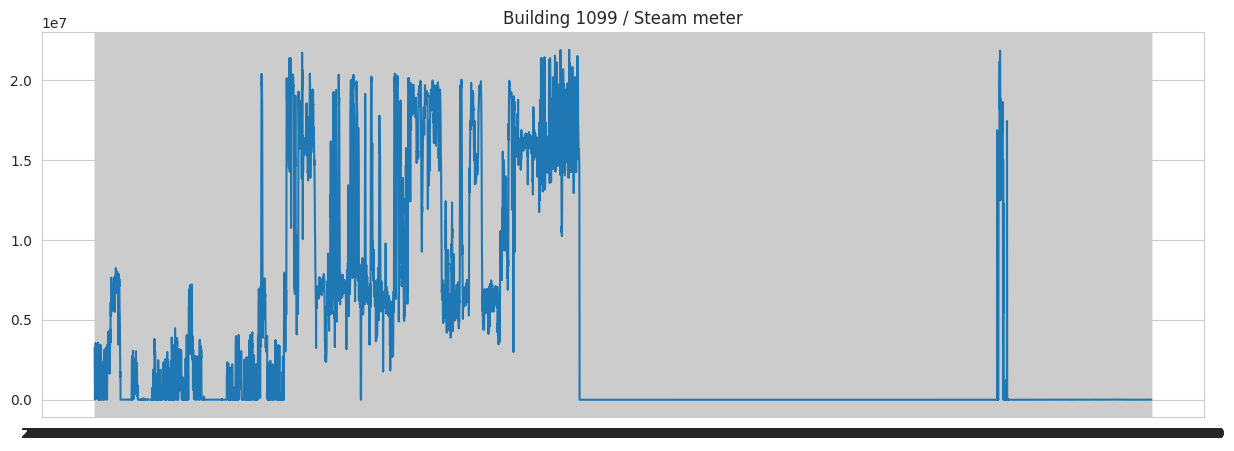

In [4]:
# 해당 건물의 시계열 패턴 확인 - 튀는 게 특정 기간인지 전체인지
subset = df[(df['building_id']==1099) & (df['meter']==2)].sort_values('timestamp')
plt.figure(figsize=(15,5))
plt.plot(subset['timestamp'], subset['meter_reading'])
plt.title('Building 1099 / Steam meter')
plt.show()

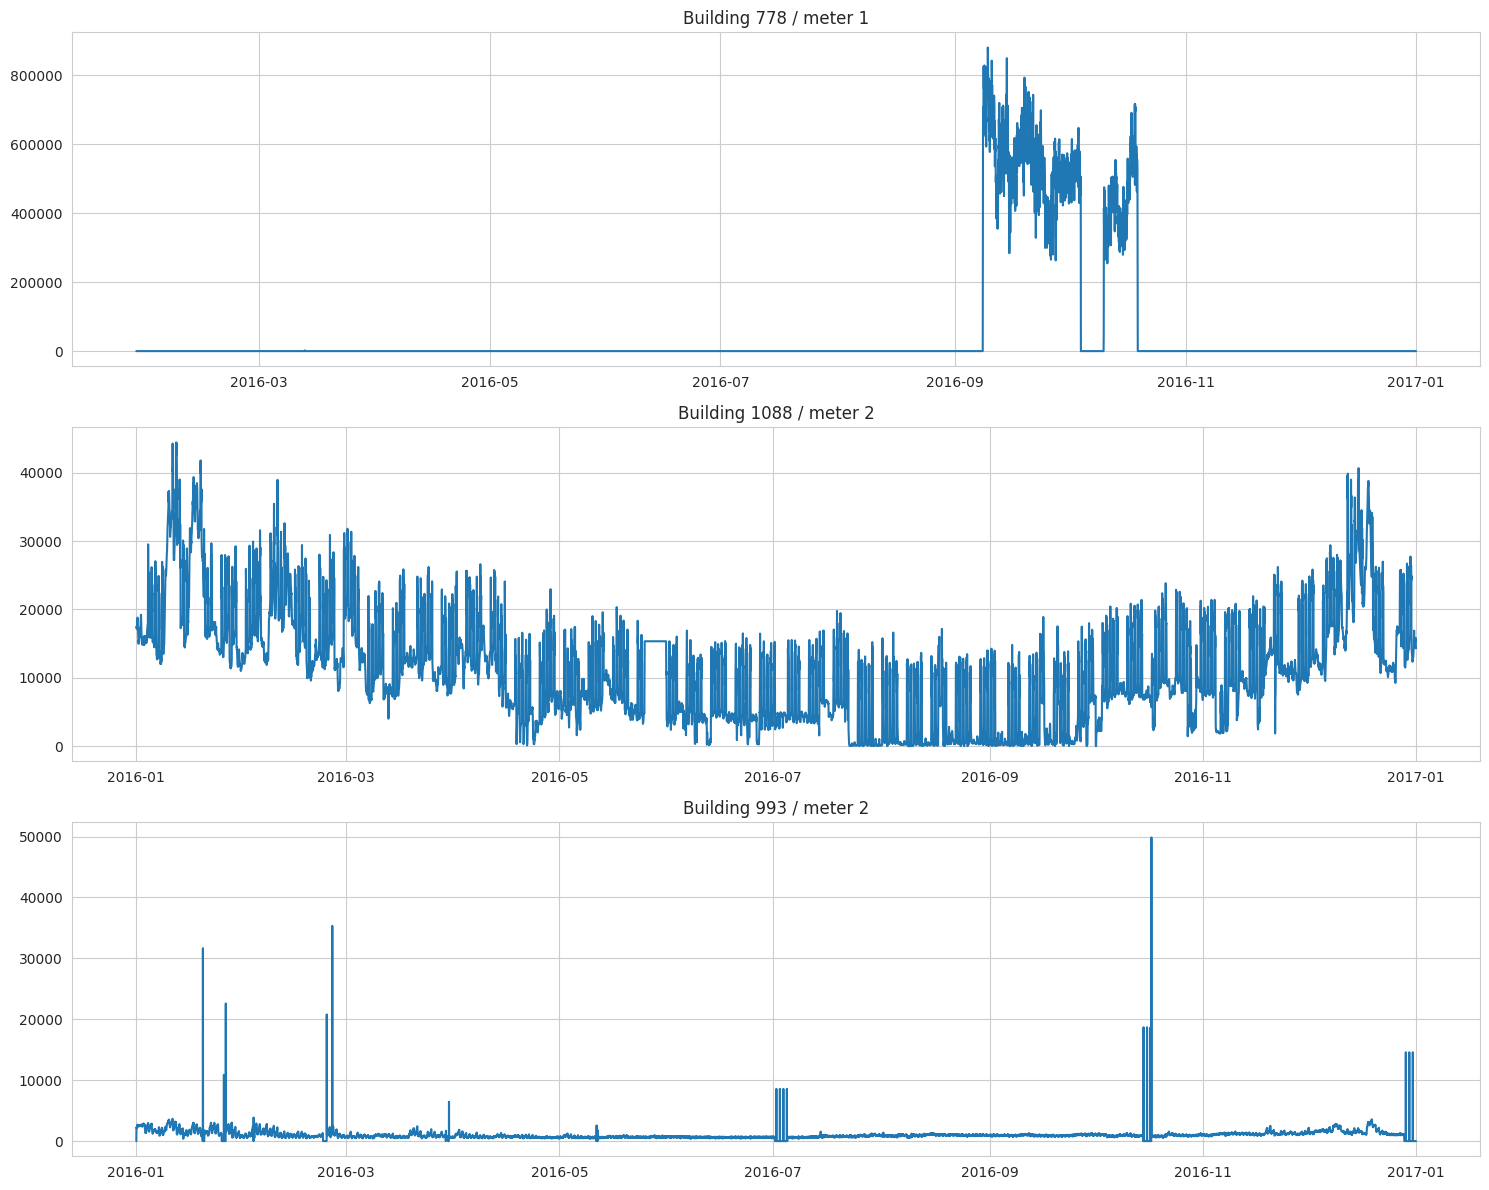

In [9]:
# 상위 이상치 건물들 시계열 한번에 확인
suspect_buildings = [(778, 1), (1088, 2), (993, 2)]  # top_outliers에서 확인한 조합들로 채우기

fig, axes = plt.subplots(len(suspect_buildings), 1, figsize=(15, 4*len(suspect_buildings)))
for ax, (bid, m) in zip(axes, suspect_buildings):
    sub = df[(df['building_id']==bid) & (df['meter']==m)].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['meter_reading'])
    ax.set_title(f'Building {bid} / meter {m}')
plt.tight_layout()
plt.show()

In [5]:
df_clean = df[~((df['building_id']==1099) & (df['meter']==2))].copy()

print(f'제거 전: {len(df)}행 → 제거 후: {len(df_clean)}행')

제거 전: 20216100행 → 제거 후: 20207316행


In [7]:
# 최종 제외 리스트
exclude_list = [(1099, 2), (778, 1)]

df_clean = df.copy()
for bid, m in exclude_list:
    df_clean = df_clean[~((df_clean['building_id']==bid) & (df_clean['meter']==m))]

# 993처럼 순간 스파이크만 있는 경우 - 건물별 IQR 기준 클리핑
def clip_spikes(group):
    q99 = group['meter_reading'].quantile(0.99)
    group['meter_reading'] = group['meter_reading'].clip(upper=q99)
    return group

mask_993 = (df_clean['building_id']==993) & (df_clean['meter']==2)
df_clean.loc[mask_993] = clip_spikes(df_clean.loc[mask_993].copy())
# 993은 위 클리핑 함수 적용
mask_993 = (df_clean['building_id']==993) & (df_clean['meter']==2)
df_clean.loc[mask_993] = clip_spikes(df_clean.loc[mask_993].copy())

## 결측치 처리

In [8]:
# ===== 결측치 처리 (전체) =====

# 0. site_id + timestamp 순으로 정렬 (보간을 위해 필수)
df_clean = df_clean.sort_values(['site_id', 'timestamp'])

# 1. 기상 변수 - site_id별 시간순 선형 보간
weather_cols = ['air_temperature', 'dew_temperature', 'sea_level_pressure',
                 'wind_direction', 'wind_speed', 'cloud_coverage']

df_clean[weather_cols] = df_clean.groupby('site_id')[weather_cols].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# 2. cloud_coverage - 결측이 많아(43%) 보간 후에도 남는 결측은 전체 중앙값으로 2차 대체
df_clean['cloud_coverage'] = df_clean['cloud_coverage'].fillna(df_clean['cloud_coverage'].median())

# 3. precip_depth_1_hr - 결측 = 강수 없음(0)으로 대체
df_clean['precip_depth_1_hr'] = df_clean['precip_depth_1_hr'].fillna(0)

# 4. year_built - building_age 파생 후 결측은 중앙값 대체
df_clean['building_age'] = 2016 - df_clean['year_built']
df_clean['building_age'] = df_clean['building_age'].fillna(df_clean['building_age'].median())

# 5. floor_count - 결측 비율 너무 높아(82%) feature 제외, flag만 남김
df_clean['has_floor_count'] = df_clean['floor_count'].notnull().astype(int)
df_clean = df_clean.drop(columns=['floor_count', 'year_built'])

# 6. time_diff - groupby 첫 행이라 계산 안 된 결측은 0으로
df_clean['time_diff'] = df_clean['time_diff'].fillna(0)

# 7. 최종 확인 - 남은 결측치가 있으면 (특정 site가 통째로 결측이라 보간 실패한 경우) 전체 중앙값으로 안전하게 마무리
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print('보간 후에도 남은 결측치 - 2차 대체 진행:')
    print(remaining_missing)
    for col in remaining_missing.index:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(df_clean.isnull().sum().sum(), '개 결측치 남음')  # 0이 나와야 정상

보간 후에도 남은 결측치 - 2차 대체 진행:
sea_level_pressure    781776
dtype: int64
0 개 결측치 남음


In [9]:
# 최종 결측치 확인
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(remaining_missing)

Series([], dtype: int64)


In [10]:
# log 변환 컬럼 확정
df_clean['log_meter_reading'] = np.log1p(df_clean['meter_reading'])

In [11]:
#meter별 분리 상관관계 재확인
for m in df_clean['meter'].unique():
    sub = df_clean[df_clean['meter']==m]
    corr_val = sub[['log_meter_reading','air_temperature']].corr().iloc[0,1]
    print(f'meter={m}: air_temperature 상관계수 = {corr_val:.3f}')

meter=0: air_temperature 상관계수 = -0.004
meter=1: air_temperature 상관계수 = 0.436
meter=3: air_temperature 상관계수 = -0.419
meter=2: air_temperature 상관계수 = -0.410


In [13]:
# 전처리 완료본 저장 (feature engineering 전)
df_clean.to_csv('/content/drive/MyDrive/취업 포폴/ashrae 에너지 예측 분석/data collection/df_preprocessed.csv', index=False)
print(f'저장 완료: {df_clean.shape}')

저장 완료: (20199231, 18)
